In [1]:
import pandas as pd
import numpy as np

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')
#%%
df.head(3)
#%% md

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,0.000061,2.627605e-05,0.00044,1.102785,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0.000005,6.089453e-04,0.00000,0.006465,0.000000,0.000000,0.006470,6.089453e-04,0.000000,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0.000006,2.558511e-07,0.00000,0.007662,0.000000,0.000000,0.007668,2.558511e-07,0.000000,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


In [ ]:
## 3. Feature engineering

price_df = pd.read_csv('/content/price_data (1).csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%m/%d/%Y')
price_df.head()
#%%
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [ ]:
df = pd.merge(df, diff, on='id', how='left')
df['offpeak_diff_dec_january_energy'] = df['offpeak_diff_dec_january_energy'].fillna(0)
df['offpeak_diff_dec_january_power'] = df['offpeak_diff_dec_january_power'].fillna(0)

reference_date = df['date_activ'].max()
df['tenure_days'] = (reference_date - df['date_activ']).dt.days

df['log_cons_12m'] = np.log10(df['cons_12m'] + 1)
df['log_cons_gas_12m'] = np.log10(df['cons_gas_12m'] + 1)
df['log_forecast_cons_12m'] = np.log10(df['forecast_cons_12m'] + 1)

df = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], prefix=['channel', 'origin'])


unused_cols = ['id', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal', 'cons_12m', 'cons_gas_12m', 'forecast_cons_12m']
df_final = df.drop(columns=unused_cols)

print(f"تم تجهيز البيانات! الجدول الجديد فيه {df_final.shape[1]} ميزة (Feature).")
df_final.head()

تم تجهيز البيانات! الجدول الجديد فيه 54 ميزة (Feature).


,cons_last_month,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,tenure_days,log_cons_12m,log_cons_gas_12m,log_forecast_cons_12m,channel_MISSING,channel_epumfxlbckeskwekxbiuasklxalciiuu,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_fixdbufsefwooaasfcxdxadsiekoceaa,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_sddiedcslfslkckwlfkdpoeeailfpeds,channel_usilxuppasemubllopkaafesmlibmsdf,origin_MISSING,origin_ewxeelcelemmiwuafmddpobolfuxioce,origin_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_ldkssxwpmemidmecebumciepifcamkci,origin_lxidpiddsbxsbosboudacockeimpuepw,origin_usapbepcfoloekilkwsdiboslwaxobdp
0,0,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,43.648,0.000061,2.627605e-05,0.000440,1.102785,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,0.020057,3.700961,443,0.000000,4.739944,0.000000,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,0,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,13.800,0.000005,6.089453e-04,0.000000,0.006465,0.000000,0.000000,0.006470,6.089453e-04,0.000000,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,-0.003767,0.177779,1837,3.668479,0.000000,2.280920,True,False,False,False,False,False,False,False,False,False,True,False,False,False
2,0,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,13.856,0.000006,2.558511e-07,0.000000,0.007662,0.000000,0.000000,0.007668,2.558511e-07,0.000000,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,-0.004670,0.177779,1599,2.736397,0.000000,1.689841,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,0,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,13.200,0.000005,0.000000e+00,0.000000,0.006465,0.000000,0.000000,0.006470,0.000000e+00,0.000000,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,-0.004547,0.177779,1616,3.200029,0.000000,2.382089,False,False,False,False,False,True,False,False,False,False,True,False,False,False
4,526,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,19.800,0.000015,3.552481e-06,0.000003,0.005429,0.001954,0.000869,0.005444,1.957971e-03,0.000871,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,-0.006192,0.162916,1692,3.646011,0.000000,2.650065,True,False,False,False,False,False,False,False,False,False,True,False,False,False


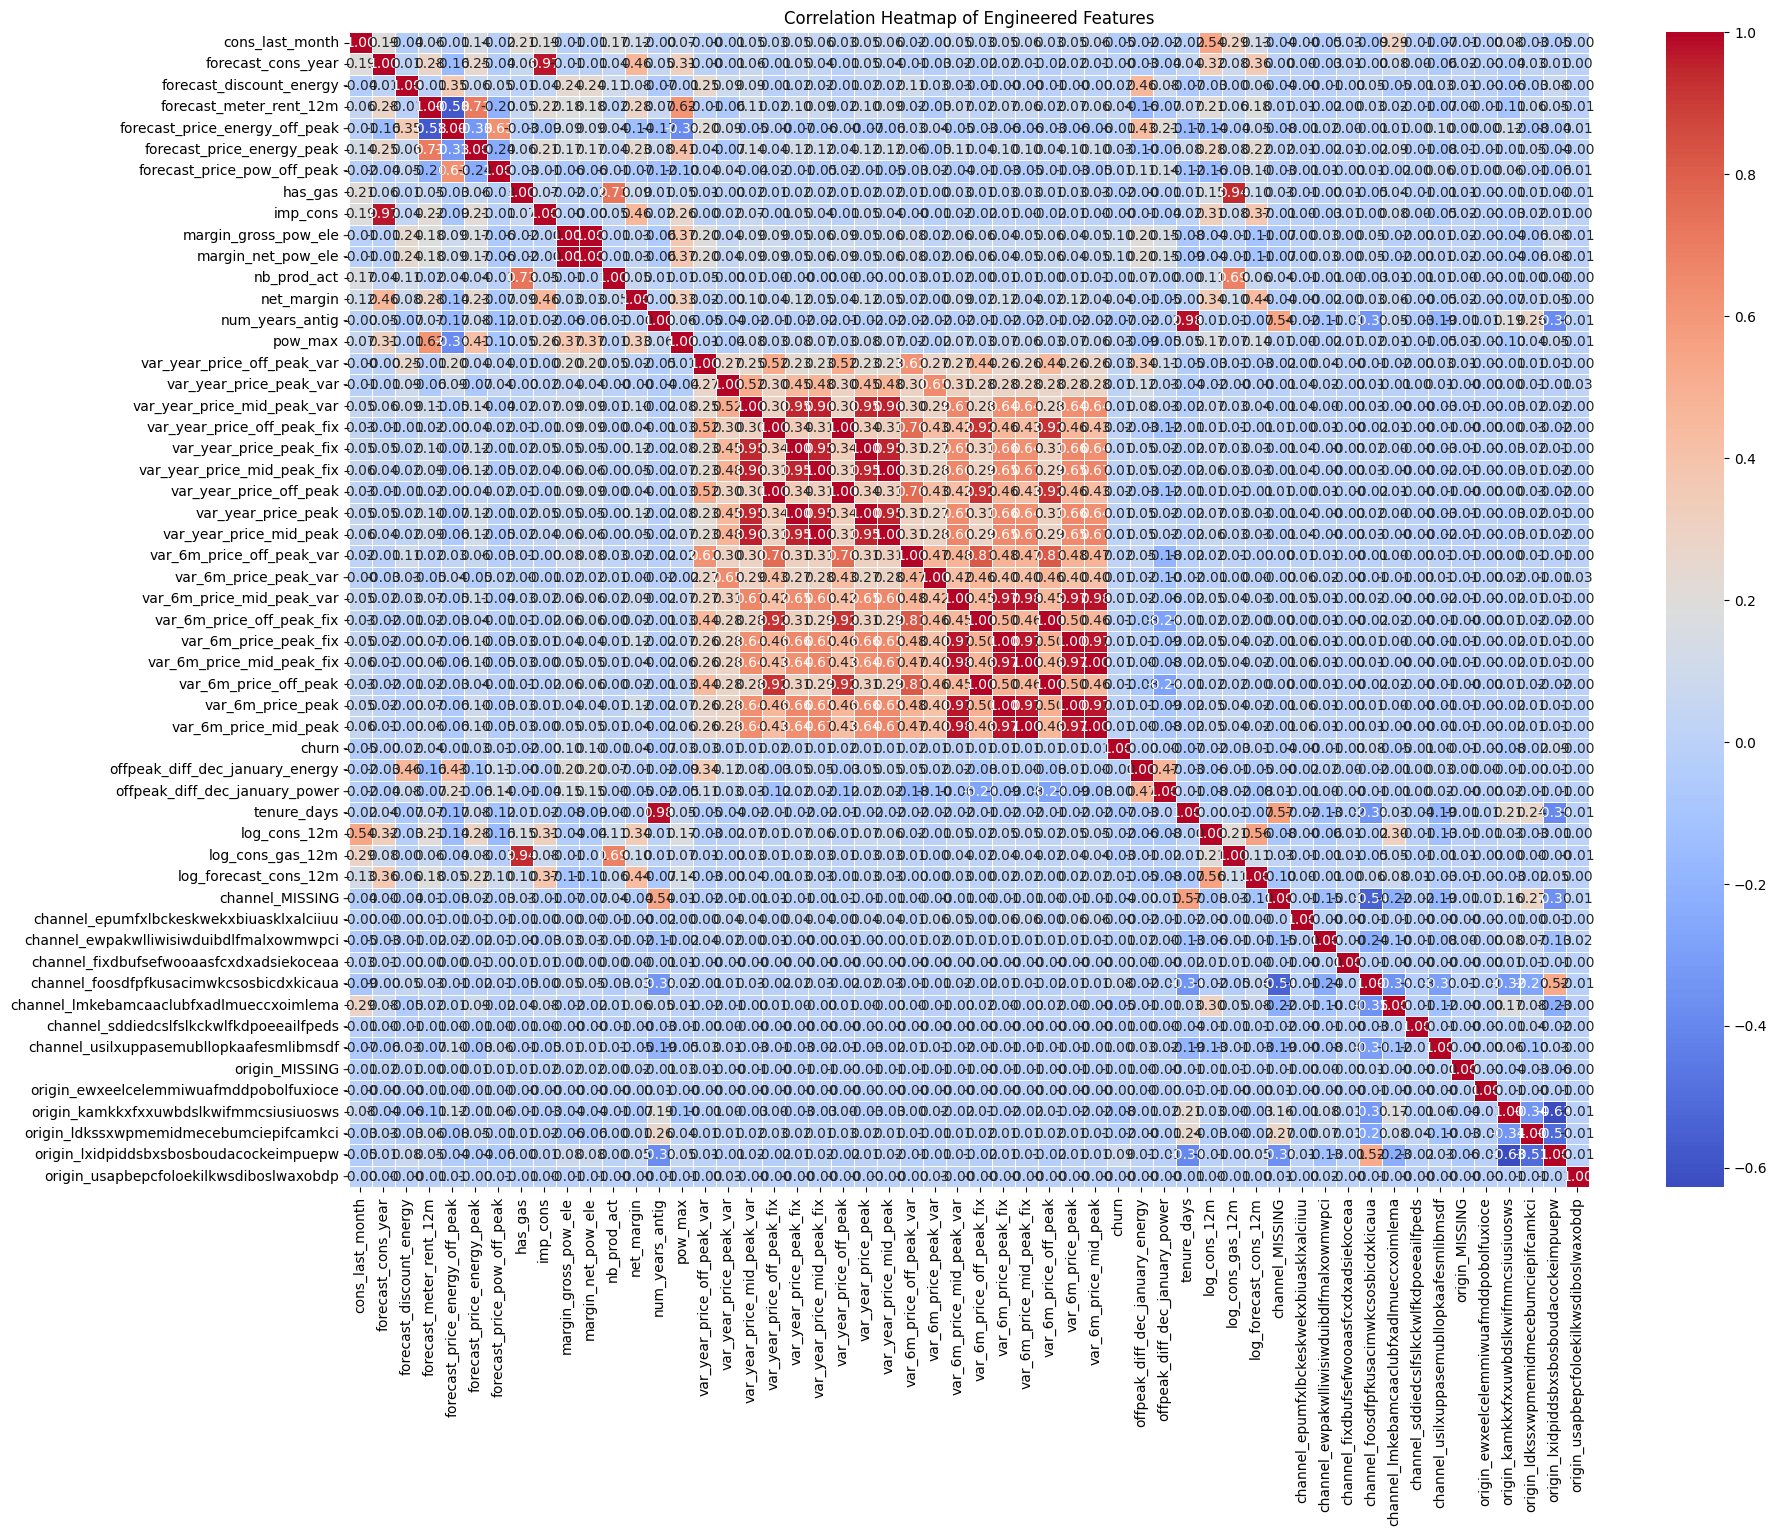

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Convert 'has_gas' column from 't'/'f' to 1/0
# df_final['has_gas'] = df_final['has_gas'].map({'t': 1, 'f': 0})

# # حساب مصفوفة الارتباط
# corr = df_final.corr()

# # رسم الـ Heatmap
# plt.figure(figsize=(20, 15))
# sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
# plt.title('Correlation Heatmap of Engineered Features')
# plt.show()

Summary of Feature Engineering StepsIn this task, we transformed the raw data into a structured set of features optimized for the Random Forest model. Our key actions were:Price Shock Feature (Addition):Following Estelle's hypothesis, we calculated the difference between January and December prices for both energy and power. This captures the "price shock" that might trigger a customer to churn.Temporal Feature Engineering (Mutation):We transformed raw date columns (like date_activ) into a numerical Tenure feature (total days with the company). Machine learning models struggle with dates but thrive on numerical durations.Handling Skewed Distributions (Transformation):Recognizing the high Right-Skewness in consumption data, we applied a Logarithmic Transformation ($\log_{10}(x+1)$). This stabilizes the variance and compresses outliers, making it easier for the model to find patterns.Categorical Encoding (Transformation):We applied One-Hot Encoding to categorical variables such as channel_sales and origin_up. This converted non-numeric labels into binary (True/False) vectors that the algorithm can process mathematically.Dimensionality Reduction (Cleanup):We dropped redundant columns, including unique IDs and original dates, to reduce noise and prevent Overfitting, ensuring the model focuses only on the most predictive features.